Dec -4, 2025 : Question 2. Ice Cream Sales Analysis - Using Arima Model 

In [1]:
#Time Series Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ice_cream.csv")
print(df.head(5))
print(df.info())

         date     sale
0  1972-01-01  59.9622
1  1972-02-01  67.0605
2  1972-03-01  74.2350
3  1972-04-01  78.1120
4  1972-05-01  84.7636
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    577 non-null    object 
 1   sale    577 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.1+ KB
None


In [3]:
df['date'] = pd.to_datetime(df['date'])
print(df.info())
df.set_index('date',inplace = True)      #inplace will make the change permanent to the DF
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    577 non-null    datetime64[ns]
 1   sale    577 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 9.1 KB
None
               sale
date               
1972-01-01  59.9622
1972-02-01  67.0605
1972-03-01  74.2350
1972-04-01  78.1120
1972-05-01  84.7636


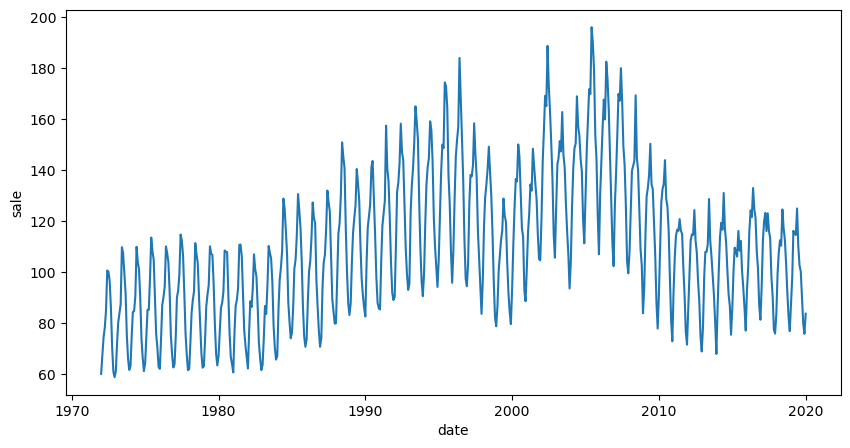

In [4]:
#Visualize the time series
plt.figure(figsize=(10,5))
sns.lineplot(data = df, x=df.index, y=df.sale)
plt.show()

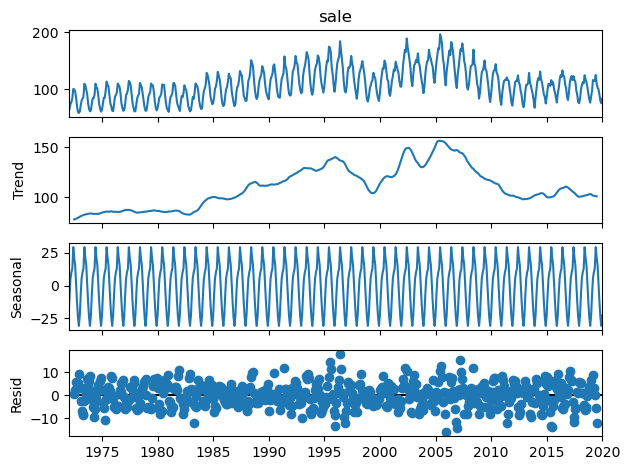

In [5]:
#Check further for seasonality and trend by doing decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df.sale, period =12)
fig =decomposition.plot()
plt.show()

In [6]:
#to check stationary
#rolling mean and std devfor 12 months
df['rollMean'] = df.sale.rolling(window =12).mean()
df['rollStd'] = df.sale.rolling(window = 12).std()


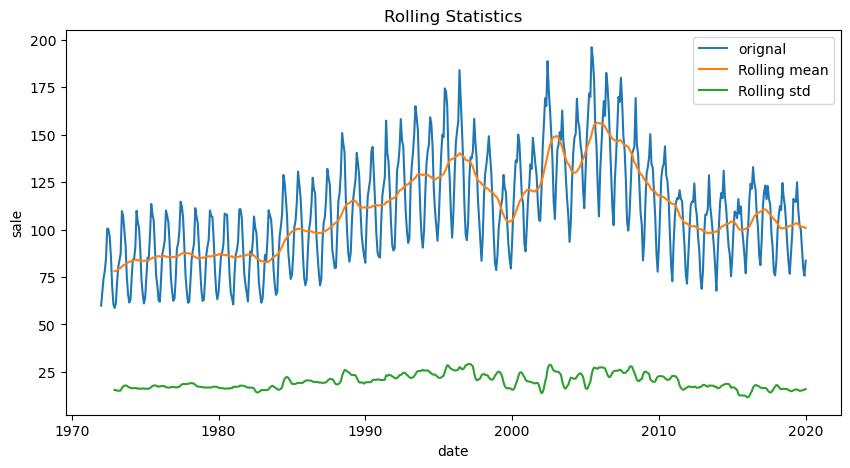

In [7]:
#plot orignal serires withrolling mean and std dev
plt.figure(figsize=(10,5))
sns.lineplot(data=df,x=df.index, y = df.sale, label="orignal")
sns.lineplot(data=df,x=df.index, y = df.rollMean, label="Rolling mean")
sns.lineplot(data=df,x=df.index, y = df.rollStd, label="Rolling std")
plt.title("Rolling Statistics")
plt.show()

ADF p-value: 0.4015
The time series is not stationary (fail to reject H0).


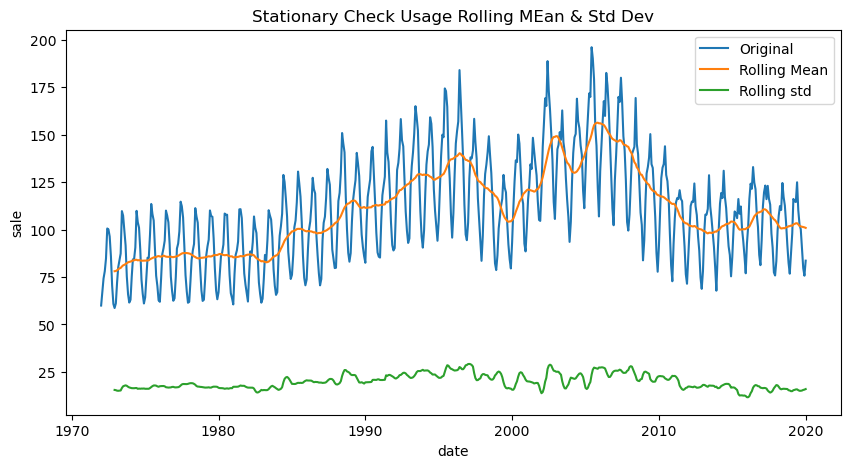

In [8]:
#define the function for stationary check
def test_stationary(dataFrame, var):
    dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
    dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()

    from statsmodels.tsa.stattools import adfuller
    adf_result = adfuller(dataFrame[var])
    p_value = adf_result[1]

    print(f"ADF p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("The time series is stationary(reject H0).")
    else:
        print("The time series is not stationary (fail to reject H0).")

    #plot
    plt.figure(figsize=(10,5))
    sns.lineplot(data=dataFrame, x=dataFrame.index, y=var, label='Original')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollMean',label='Rolling Mean')
    sns.lineplot(data=dataFrame, x=dataFrame.index, y='rollStd', label='Rolling std')
    plt.title("Stationary Check Usage Rolling MEan & Std Dev")
    plt.legend()
    plt.show()

#calling the function to test functionality
test_stationary(df,'sale')

                sale     shift  shiftDiff
date                                     
1972-01-01   59.9622       NaN        NaN
1972-02-01   67.0605   59.9622     7.0983
1972-03-01   74.2350   67.0605     7.1745
1972-04-01   78.1120   74.2350     3.8770
1972-05-01   84.7636   78.1120     6.6516
1972-06-01  100.5960   84.7636    15.8324
1972-07-01  100.1263  100.5960    -0.4697
1972-08-01   96.3607  100.1263    -3.7656
1972-09-01   85.8007   96.3607   -10.5600
1972-10-01   70.3934   85.8007   -15.4073
1972-11-01   60.8072   70.3934    -9.5862
1972-12-01   58.6598   60.8072    -2.1474
1973-01-01   61.0996   58.6598     2.4398
1973-02-01   72.2062   61.0996    11.1066
1973-03-01   80.0984   72.2062     7.8922
1973-04-01   83.9059   80.0984     3.8075
1973-05-01   87.3712   83.9059     3.4653
1973-06-01  109.7467   87.3712    22.3755
1973-07-01  107.3748  109.7467    -2.3719
1973-08-01   99.6631  107.3748    -7.7117
ADF p-value: 0.0000
The time series is stationary(reject H0).


C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_20240\3403239772.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollMean'] = dataFrame[var].rolling(window=12).mean()
C:\Users\dbda.STUDENTSDC\AppData\Local\Temp\ipykernel_20240\3403239772.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame['rollStd'] = dataFrame[var].rolling(window=12).std()


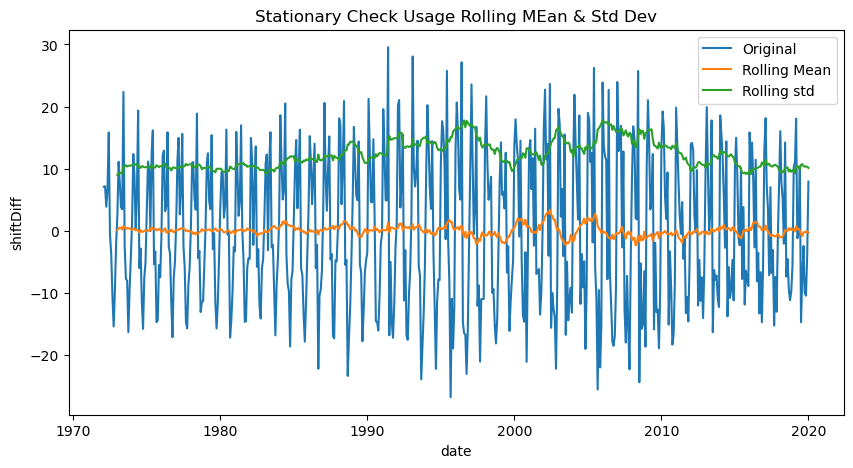

In [9]:
ice_df = df[['sale']].copy()
#Try shift diff of 1
ice_df['shift'] = ice_df.sale.shift(1)
ice_df['shiftDiff'] = ice_df['sale'] - ice_df['shift']
print(ice_df.head(20))
#Test stationarity
test_stationary(ice_df.dropna(),'shiftDiff')

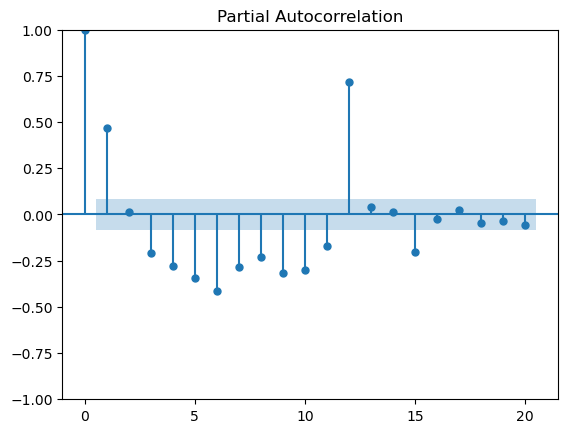

In [10]:
#Now ARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_pacf(ice_df['shiftDiff'].dropna(),lags=20)
plt.show()

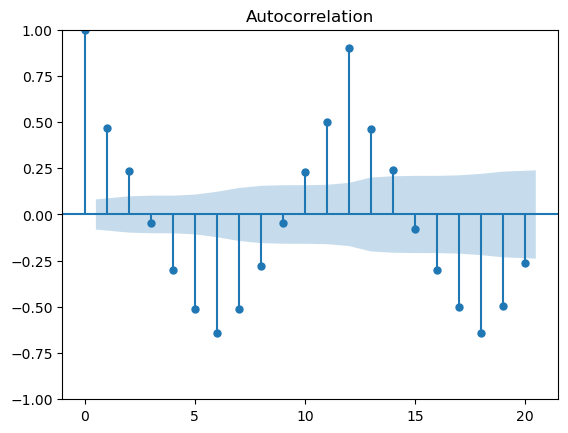

In [11]:
#Now let us take this value as p =1 and find q for  which we need ACF
plot_acf(ice_df['shiftDiff'].dropna(), lags =20)
plt.show()

In [12]:
#Build Arima model
train = ice_df[: round(len(ice_df)*70/100)]  #take the first 70% data
print(train.head()) #just to check where it starts

test = ice_df[round(len(ice_df)*71/100):] #Take the last 30% of data starting from 71%
print(test.head())

model = ARIMA(train['sale'], order =(12,0,0)) #Parameters: p,d,q
model_fit =model.fit()
prediction = model_fit.predict(start = test.index[0], end = test.index[-1])
ice_df['arimaPred'] = prediction
print(ice_df.tail())

               sale    shift  shiftDiff
date                                   
1972-01-01  59.9622      NaN        NaN
1972-02-01  67.0605  59.9622     7.0983
1972-03-01  74.2350  67.0605     7.1745
1972-04-01  78.1120  74.2350     3.8770
1972-05-01  84.7636  78.1120     6.6516
                sale     shift  shiftDiff
date                                     
2006-03-01  156.3691  144.3001    12.0690
2006-04-01  167.7272  156.3691    11.3581
2006-05-01  159.9362  167.7272    -7.7910
2006-06-01  182.6261  159.9362    22.6899
2006-07-01  176.0375  182.6261    -6.5886


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                sale     shift  shiftDiff   arimaPred
date                                                 
2019-09-01  100.1741  102.6085    -2.4344  162.433095
2019-10-01   90.1684  100.1741   -10.0057  155.300524
2019-11-01   79.7223   90.1684   -10.4461  146.127529
2019-12-01   75.7094   79.7223    -4.0129  137.317571
2020-01-01   83.6290   75.7094     7.9196  131.160877


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train['sale'],order=(11,0,0), seasonal_order=(1,0,0,12))
model_fit = model.fit()
prediction = model_fit.predict(start=test.index[0], end =test.index[-1])
ice_df['sarimaxPred'] = prediction
print(ice_df.tail())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                sale     shift  shiftDiff   arimaPred  sarimaxPred
date                                                              
2019-09-01  100.1741  102.6085    -2.4344  162.433095   116.440272
2019-10-01   90.1684  100.1741   -10.0057  155.300524   111.832640
2019-11-01   79.7223   90.1684   -10.4461  146.127529    94.708479
2019-12-01   75.7094   79.7223    -4.0129  137.317571    86.170767
2020-01-01   83.6290   75.7094     7.9196  131.160877    98.055070


               sale    shift  shiftDiff  arimaPred  sarimaxPred
date                                                           
1972-01-01  59.9622      NaN        NaN        NaN          NaN
1972-02-01  67.0605  59.9622     7.0983        NaN          NaN
1972-03-01  74.2350  67.0605     7.1745        NaN          NaN
1972-04-01  78.1120  74.2350     3.8770        NaN          NaN
1972-05-01  84.7636  78.1120     6.6516        NaN          NaN


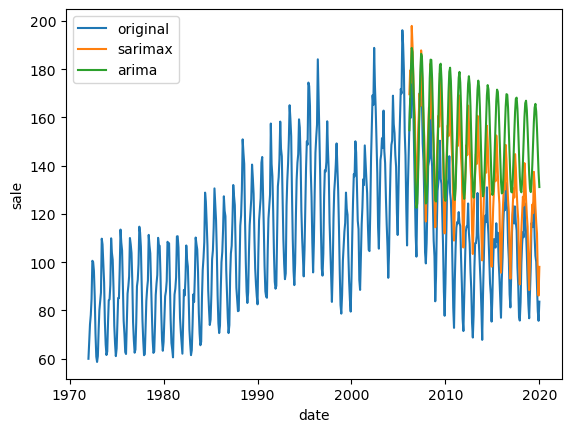

In [14]:
#plot
ice_df.dropna()
print(ice_df.head())
sns.lineplot(data=ice_df, x=ice_df.index, y ="sale", label = "original")
sns.lineplot(data=ice_df, x=ice_df.index, y='sarimaxPred',label ="sarimax")
sns.lineplot(data=ice_df, x=ice_df.index, y='arimaPred', label = "arima")
plt.show()
#SARIMAX predictions are much more accurate


In [15]:
#Future Prediction
#First check the laste date in our dataset
print(ice_df.tail())

                sale     shift  shiftDiff   arimaPred  sarimaxPred
date                                                              
2019-09-01  100.1741  102.6085    -2.4344  162.433095   116.440272
2019-10-01   90.1684  100.1741   -10.0057  155.300524   111.832640
2019-11-01   79.7223   90.1684   -10.4461  146.127529    94.708479
2019-12-01   75.7094   79.7223    -4.0129  137.317571    86.170767
2020-01-01   83.6290   75.7094     7.9196  131.160877    98.055070


In [16]:
#MS: Month start Frequency
#Create a dataframe to hold index values from 01.02.2020 to 01.12.2025
futureDate = pd.DataFrame(pd.date_range(start="2020-02-01", end="2025-12-01", freq="MS"),columns=["Dates"])
futureDate.set_index("Dates", inplace=True)
print(futureDate.head())

Empty DataFrame
Columns: []
Index: [2020-02-01 00:00:00, 2020-03-01 00:00:00, 2020-04-01 00:00:00, 2020-05-01 00:00:00, 2020-06-01 00:00:00]


2020-02-01    107.645720
2020-03-01    113.746129
2020-04-01    120.693602
2020-05-01    117.253854
2020-06-01    133.925214
                 ...    
2025-08-01    105.222160
2025-09-01     99.594211
2025-10-01     95.653190
2025-11-01     81.006477
2025-12-01     73.703964
Freq: MS, Name: predicted_mean, Length: 71, dtype: float64


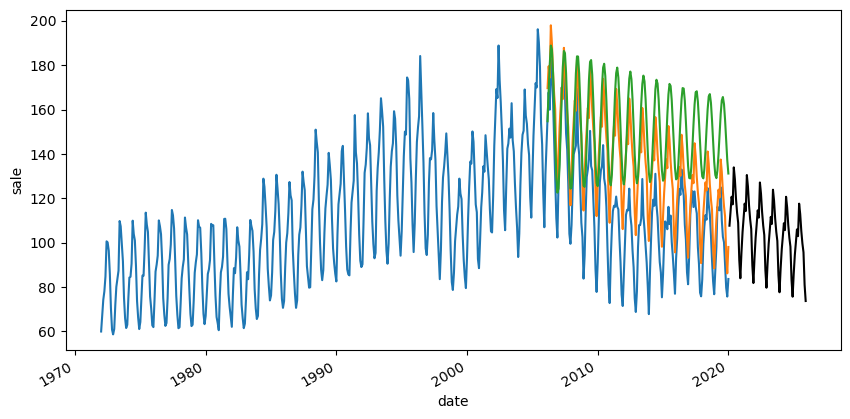

In [17]:
#predict and print
print(model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1]))

#plot
ice_df.dropna()
plt.figure(figsize=(10,5))
sns.lineplot(data=ice_df, x=ice_df.index, y="sale")
sns.lineplot(data=ice_df, x=ice_df.index, y="sarimaxPred")
sns.lineplot(data=ice_df, x=ice_df.index, y="arimaPred")
model_fit.predict(start=futureDate.index[0], end=futureDate.index[-1]).plot(color="black")
plt.show()

In [18]:
#Model evaluation
ice_df = ice_df.dropna()
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

#arima evaluation
mae = mean_absolute_error(ice_df["sale"],ice_df["arimaPred"])
rmse = root_mean_squared_error(ice_df["sale"],ice_df["arimaPred"])
r2 = r2_score(ice_df["sale"], ice_df["arimaPred"])
print(f"ARIMA MAE: {mae}, RMSE : {rmse}, R^2: {r2}")

ARIMA MAE: 40.077726602692444, RMSE : 44.0149686596621, R^2: -2.299308306291003


In [19]:
ice_df = ice_df.dropna()
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

#arima evaluation
mae = mean_absolute_error(ice_df["sale"],ice_df["sarimaxPred"])
rmse = root_mean_squared_error(ice_df["sale"],ice_df["sarimaxPred"])
r2 = r2_score(ice_df["sale"], ice_df["sarimaxPred"])
print(f"SARIMA MAE: {mae}, RMSE : {rmse}, R^2: {r2}")

SARIMA MAE: 24.214727055116498, RMSE : 26.49293101643311, R^2: -0.19531432374426938
